# Presentation 

## Python Audio Processing & Renaming System

A Python-based application designed to process audio files of any format, standardize their structure, and apply a fully metadata-driven naming convention.

## Core Functionality

- Automatically extracts all available ID3 metadata to ensure zero information loss  
- Translates metadata into a structured and consistent filename format  

TRkw_{track_name}ARkw{artists}MXkw{mix_name}KYkw{key}BPkw{bpm}GNkw{genre}_
RMkw_{remixers}LBkw{label}RYkw{release_year}{release_month}{release_day}PYkw{purchase_year}{purchase_month}{purchase_day}.ext


## Audio Standardization

- Converts all input files into a uniform, high-quality format  
  - Format: AIFF (.aiff)  
  - Codec: PCM (uncompressed)  
  - Bit Depth: 16-bit  
  - Sample Rate: 44.1 kHz  
  - Channels: Stereo  

## Additional Capabilities

- Preserves and aligns metadata across all processed files  
- Enables scalable organization for large music libraries  
- Prepares audio assets for downstream workflows (DJing, ML pipelines, archiving)

## Output

- Clean, standardized AIFF files  
- Fully structured filenames ready for feature extraction and ML pipelines

# Preprocess raw files 

- if files are not renamed this will do the work 

In [9]:
import os ; import pandas as pd 

from src._0_PreProcess._ms_0_music_files_export_table import _ms_music_files_export

direc = os.getcwd()                              
direc_preprocess  = f"{direc}/src/_0_PreProcess"
direc_preprocess

'/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/src/_1_Attributes/src/_0_PreProcess'

In [6]:
# get df of folder with music files 

audio_extensions = ['.m4a','.mp3', '.MP3','.Mp3' ,'.wav', '.WAV', '.flac', '.FLAC', '.aac', '.ogg', '.wma', '.au', '.aif', '.aiff']

df, df_AU, result = _ms_music_files_export(
    path_root='/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/raw/_audio_files/03_29_spkr_soundcloud_audio',
    audio_extensions=audio_extensions
)

# get id tags 
direc = "/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/src/_0_PreProcess"
exec(open(f"{direc_preprocess}/_ms_pl_info_1a_all-id-tags.py", encoding="utf-8").read())

# convert to Aiff -> change Path name and also extension 
exec(open(f"{direc_preprocess}/_ms_2_convert_to_aiff.py", encoding="utf-8").read())
df = _au_2903_i4_GET_df_aiff_FINAL(df, audio_extensions)

# FInally rename for the key word 
exec(open(f"{direc_preprocess}/_ms_3_rename_key_words.py", encoding="utf-8").read())
df = _rename_2903_i2_GET_df_confirm(df) 
exists = df['Path'].apply(os.path.exists);print("Existing:", exists.sum());print("Missing:", (~exists).sum())

# GET ALL ATTRIBUTES 

In [8]:
### >> We processed raw audio file into a normalized stage, 
## >> now we create unique IDs and extract over 100 attributes of each file

import os
import runpy

# save current dir
cwd = os.getcwd()

# move to target folder
os.chdir('/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/src/_1_Attributes')

# run script
# runpy.run_path('auto.py') # -> run for new songs 

# go back
os.chdir(cwd)

# runs new raw audio files encountered here 
# /Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/raw/_audio_files

## Metadata Encoding & Attribute Exposure

### → Encodes BPM class + LUFS (A–Z) in filename  
### → Includes acquisition year + exact BPM  
### → Stores Camelot + musical key  
### → Embeds unique track ID  
### → Appends core metadata (genre, artist, title, mix, year + more)

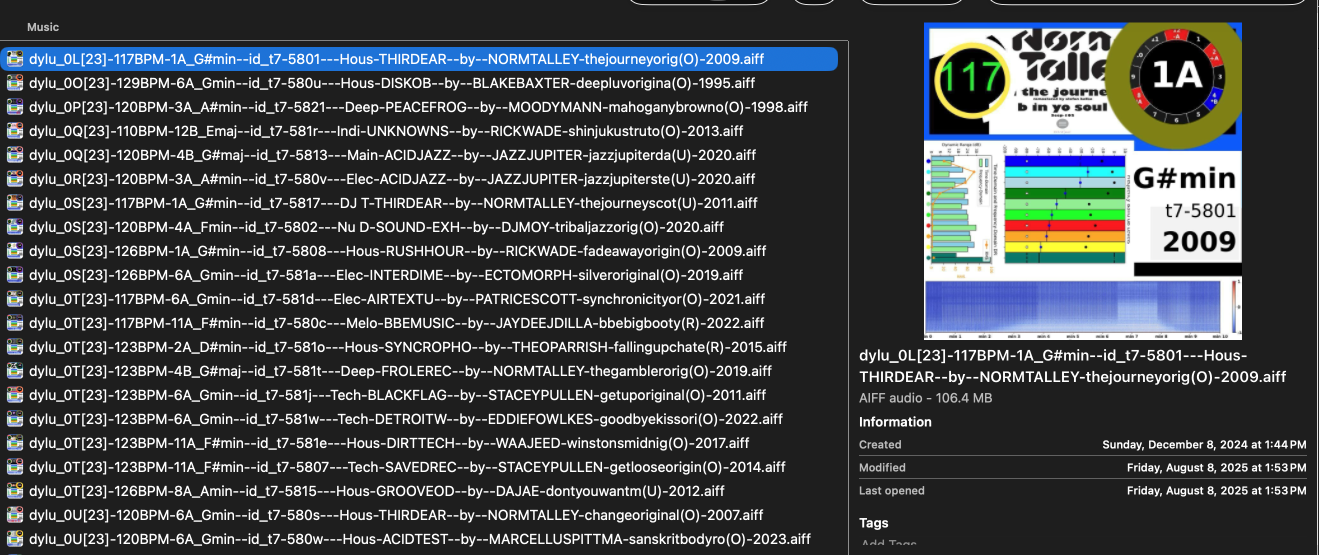

# DJ Decision Intelligence  
### Real-Time Audio Feature Dashboard & Selection Engine

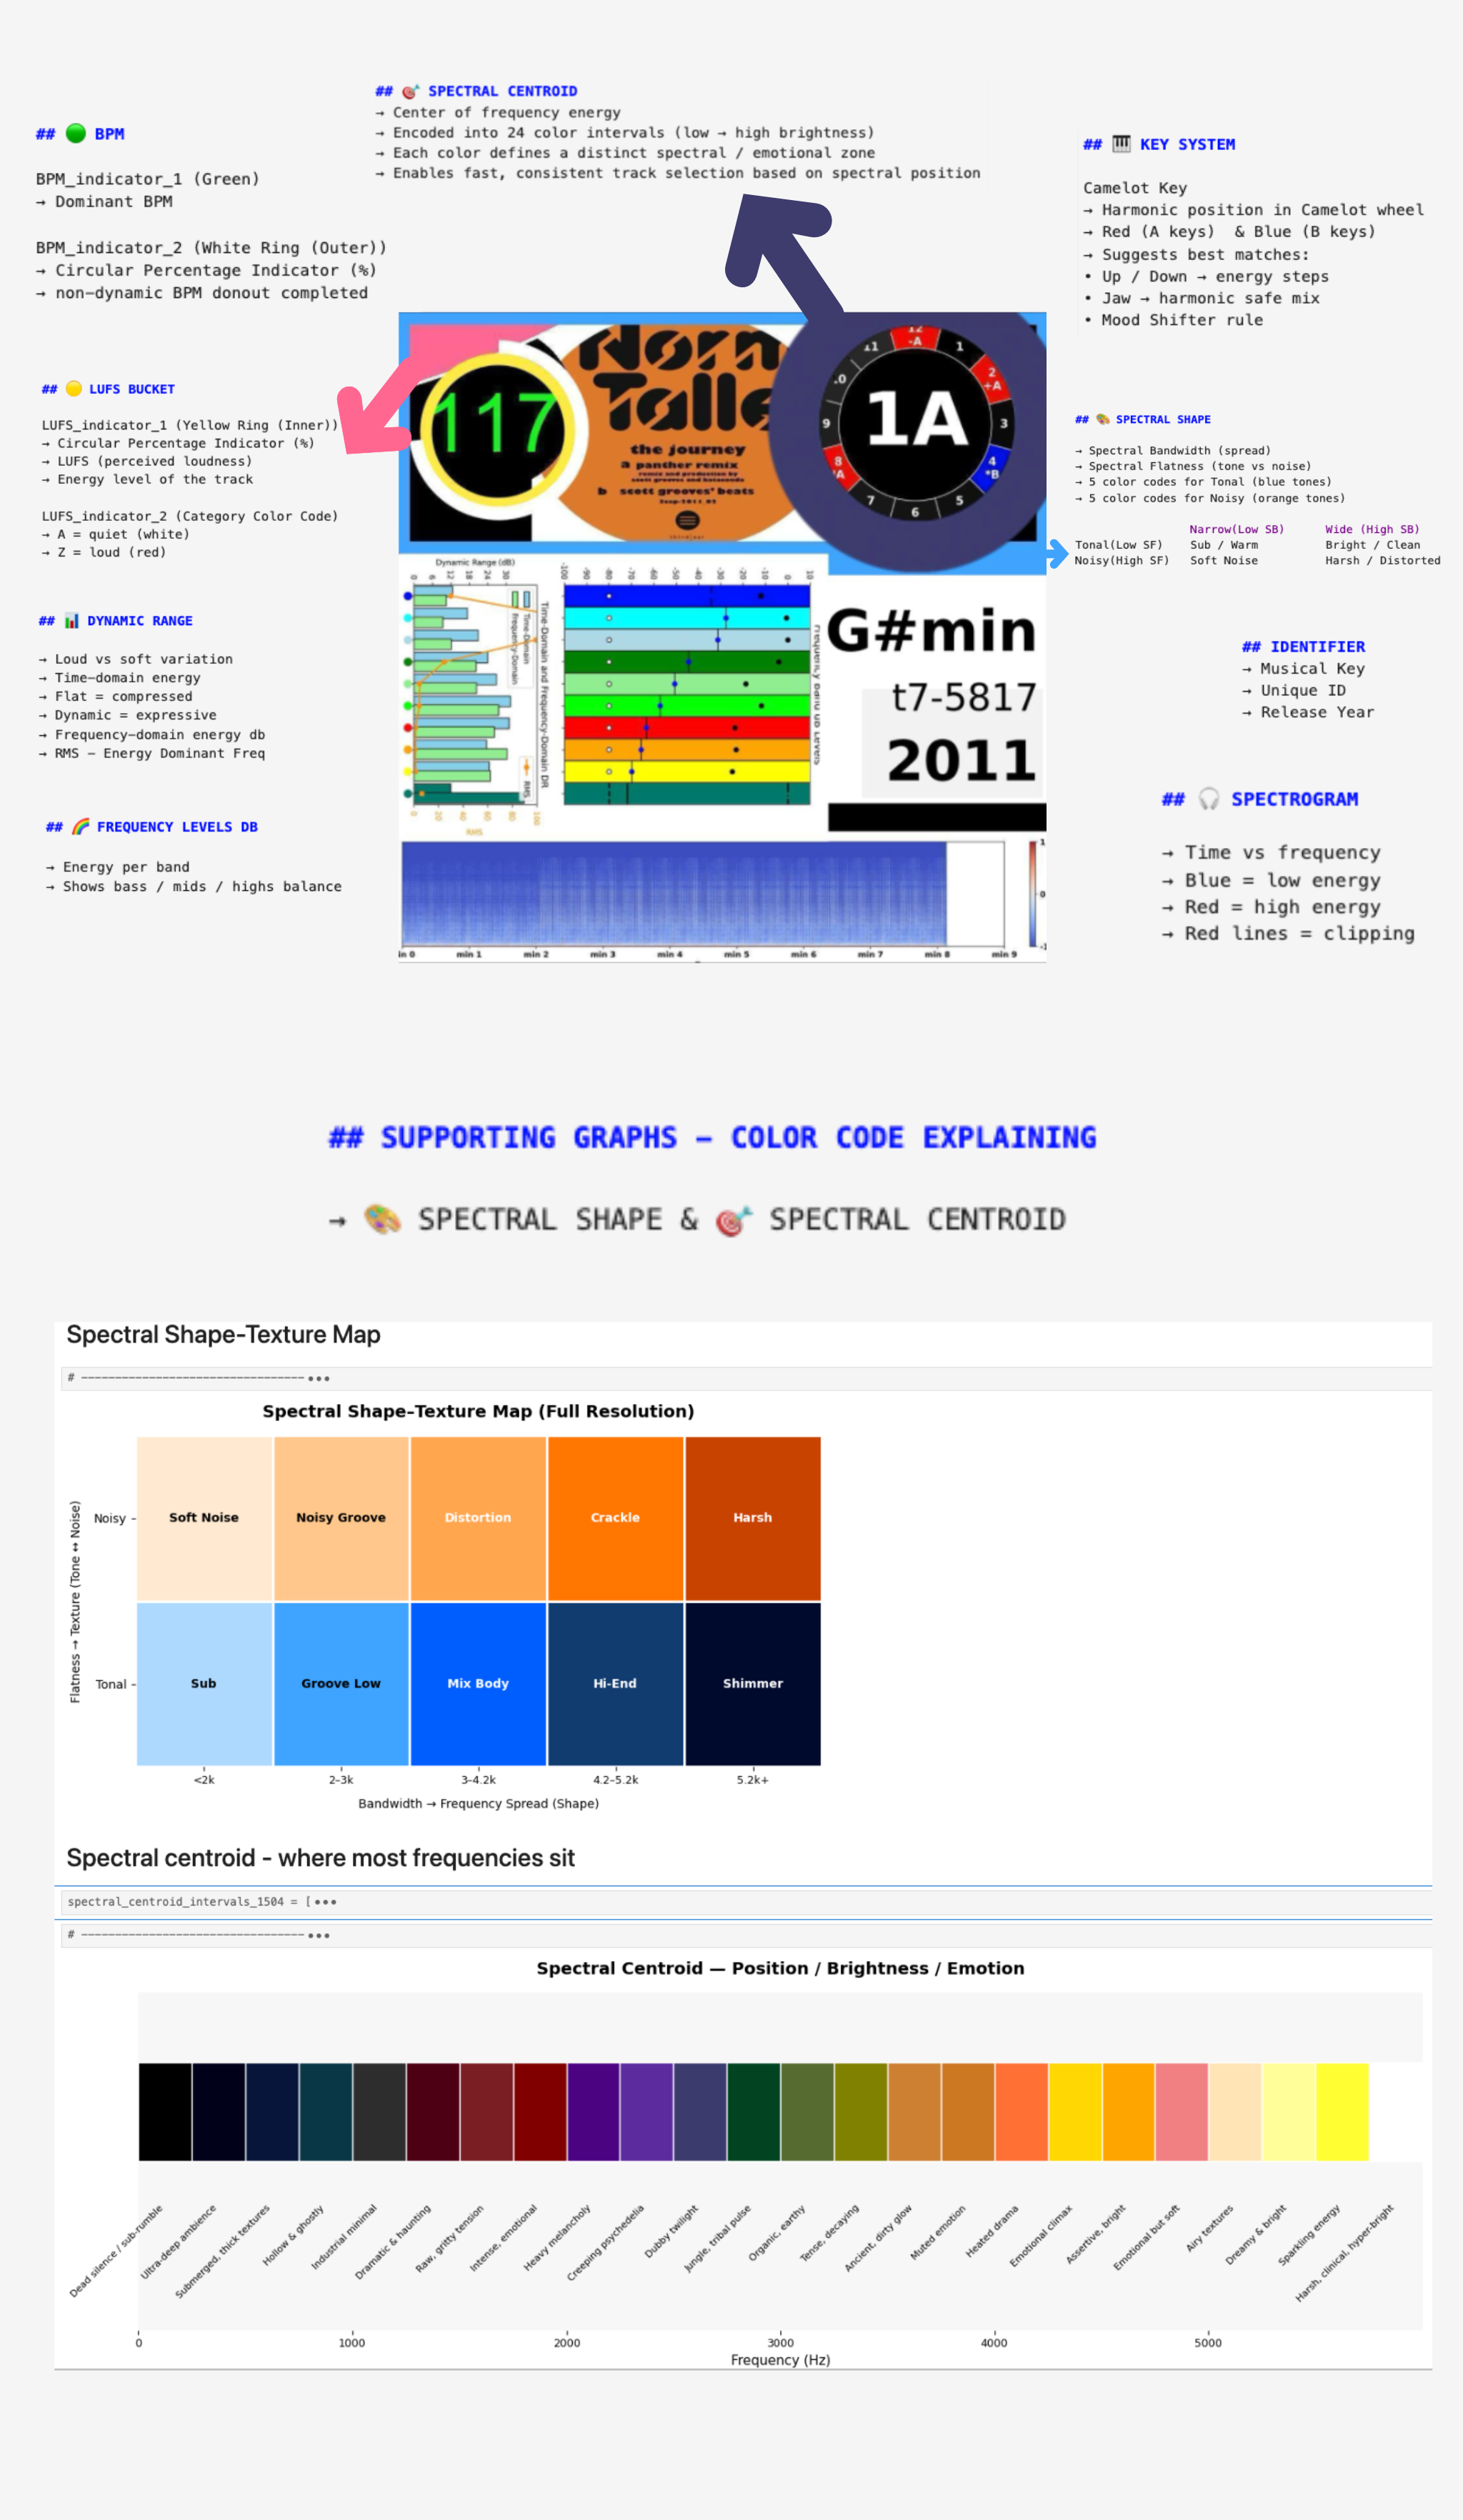

In [4]:
from PIL import Image
from IPython.display import display

img = Image.open('/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/processed/proc_cover_art_fields_1a.png');display(img)

# REKORBOX VIEW 

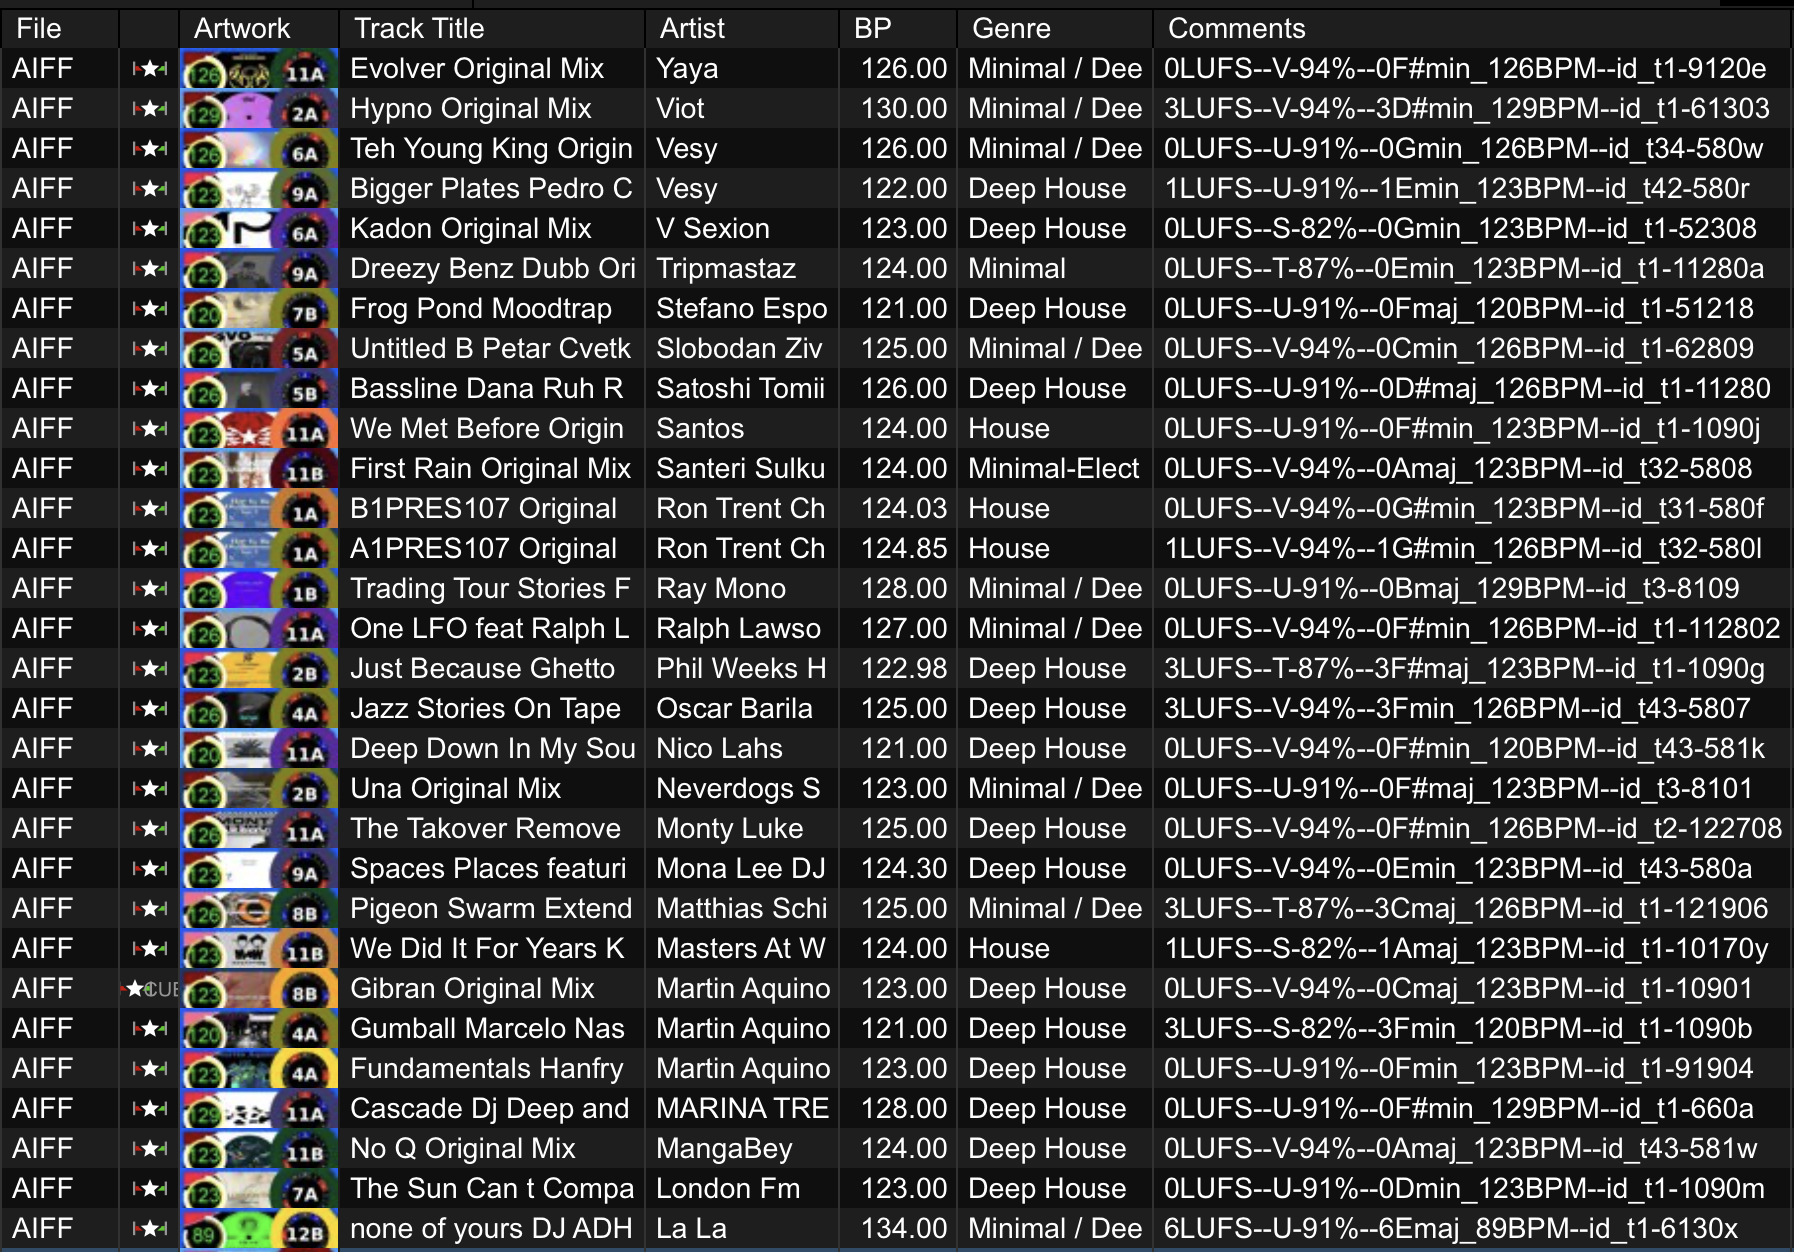

### The layout of the cover image is optimized for Rekordbox, enabling fast visual access to key track attributes directly within the browsing interface.

# MODEL Hyphothesis : Energy buckets are defined as y independent 
### HYP : ENERGY = TEXTURE + DYNAMICS 
### TEXTURE = 'Spectral_Bandwidth','spec_centroid_hz','Spectral_Flatness'
### DYNAMICS = 'ms_LUFS_norm','lufs_pct',	'dominant_bpm'	,'bpm_consistency'

In [21]:
#pd.set_option('display.max_columns', None)
import pandas as pd

pd.set_option('display.max_rows', None)        # show all rows
pd.set_option('display.max_columns', None)     # show all columns
pd.set_option('display.width', None)           # auto-detect width
pd.set_option('display.max_colwidth', None)    # show full text in each cell

# 0 LOAD modules 

In [22]:
# from src.data_loader_pkl import load_pkl_folder

# from src.data_loader_pkl import EDA_check_paths


# # from src.eda import eda_01_06_GET_report
# # from src.preprocessing import prep_features_target
# # from src.modeling import split_train_test
import pandas as pd
import os

# 1 # LOAD DATA 

In [23]:
path_name = '/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/processed/df_03_27_2026_aiff_tracks_data.pkl'

df= pd.read_pickle(path_name)

df_raw= pd.read_pickle(path_name)

print(len(df))

# check if paths exist for analized songs 

print(df['Path'].apply(lambda x: os.path.exists(x)).all())

2402
True


# KEEP NEEDED VARIABLES

In [24]:
cols_keep =  ['ID', 'Path', 'ms_lufs',  'id_cat_lufs','ms_LUFS_norm','lufs_pct',
              'bpm_consistency','bpm_consistency_cat',	'dominant_bpm'	,
              'genre', 'rel_year', 'KEY',	
               'key_file', 'remix', 'key_dj', 'key_music', 'Relative_Key',
              'Key_Up','Key_Down','Jaw_s_Mix', 'Mood_Shifter','Spectral_Bandwidth', 'Spectral_Flatness',
              'HEX_shape_texture', 'spec_centroid_hz','centroid_color','centroid_desc']
df = df[[c for c in cols_keep if c in df.columns]]

In [25]:
df.isna().sum().sort_values(ascending=False).head(120)

rel_year               187
genre                  139
ID                       0
key_music                0
centroid_color           0
spec_centroid_hz         0
HEX_shape_texture        0
Spectral_Flatness        0
Spectral_Bandwidth       0
Mood_Shifter             0
Jaw_s_Mix                0
Key_Down                 0
Key_Up                   0
Relative_Key             0
remix                    0
key_dj                   0
Path                     0
key_file                 0
KEY                      0
dominant_bpm             0
bpm_consistency_cat      0
bpm_consistency          0
lufs_pct                 0
ms_LUFS_norm             0
id_cat_lufs              0
ms_lufs                  0
centroid_desc            0
dtype: int64

# FREQ tables 

In [26]:
# ---------------------------------
# COLUMN PROFILE + CLEAN CATEGORY VALUES
# ---------------------------------

import pandas as pd
import numpy as np

# ---------------------------------
# BASE SUMMARY
# ---------------------------------
summary = pd.DataFrame({
    'missing_count' : df.isna().sum(),
    'dtype'         : df.dtypes.astype(str),
    'n_unique'      : df.nunique(dropna=True)
})

# ---------------------------------
# FLAGS
# ---------------------------------
summary['is_categorical'] = np.where(
    (summary['dtype'] == 'object') | (summary['n_unique'] < 20),
    True, False
)

summary['is_id'] = np.where(
    (summary['n_unique'] == len(df)) & (summary['missing_count'] == 0),
    True, False
)

# detect path-like columns
summary['is_path'] = summary.index.str.lower().str.contains('path')

# ---------------------------------
# NUMERICAL STATS
# ---------------------------------
num_cols = df.select_dtypes(include=np.number).columns

summary['mean'] = df[num_cols].mean()
summary['min']  = df[num_cols].min()
summary['max']  = df[num_cols].max()

# ---------------------------------
# CATEGORY VALUES (EXCLUDE ID + PATH)
# ---------------------------------
def get_cat_values(col):
    vals = sorted(col.dropna().unique())
    return " | ".join([str(v) for v in vals])

summary['cat_values'] = None

cat_cols = summary[
    (summary['is_categorical']) &
    (~summary['is_id']) &
    (~summary['is_path'])
].index

for col in cat_cols:
    summary.loc[col, 'cat_values'] = get_cat_values(df[col])

# ---------------------------------
# RANKING
# ---------------------------------
def assign_group(row):
    if row['is_id']:
        return 0
    elif row['is_categorical']:
        return 1
    else:
        return 2

summary['group_rank'] = summary.apply(assign_group, axis=1)

# ---------------------------------
# FINAL SORT
# ---------------------------------
summary = summary.sort_values(
    by=['group_rank', 'missing_count'],
    ascending=[True, False]
)

summary = summary.head(120)

summary

,missing_count,dtype,n_unique,is_categorical,is_id,is_path,mean,min,max,cat_values,group_rank
ID,0,object,2402,True,True,False,NaN,NaN,NaN,None,0
Path,0,object,2402,True,True,True,NaN,NaN,NaN,None,0
rel_year,187,object,39,True,False,False,NaN,NaN,NaN,1977 | 1979 | 1980 | 1986 | 1990 | 1992 | 1993 | 1994 | 1995 | 1996 | 1997 | 1998 | 1999 | 2000 | 2001 | 2002 | 2003 | 2004 | 2005 | 2006 | 2007 | 2008 | 2009 | 2010 | 2011 | 2012 | 2013 | 2014 | 2015 | 2016 | 2017 | 2018 | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025,1
genre,139,object,129,True,False,False,NaN,NaN,NaN,"| Abstract | Acapella | Acid | Acid, House | Afro House | Afro House | Afro Latin / Electronic | Afro Tribal | AfroLatin | Amapiano | Bass Club | Bass / Club | Bass / Cumbia | Bass House | Bass House | Blues | Booty | Breakbeat / Bass | Breaks Breakbeat UK Bass | Breaks / Breakbeat / UK Bass | COO:US##G:ghetto tech##G:ghettotech##G:ghetto house##G:chicago house##G:house# | Classic House | DJ Tools | Dance | Dance | Dance Pop | Dance / Electro Pop | Dance / Pop | Deep / Soulful House | Deep Dubstep / Grime | Deep House | Deep House | Detroit Classics | Detroit House | Detroit-Deep-House | Detroit-House | DetroitHouse | Disko Punk | Downtempo | Drum & Bass | Drum & Bass | Dubstep | Dubstep | Electro | Electro (Classic / Detroit / Modern) | Electro / Breaks | Electro House | Electronic | Electronic | Electronic / Cumbia | Electronic / Electro / Techno / House | Electronic / Tropical | Electronic, Indige | Electronica | Electronica | Folktronica | Funky House | Funky House | Ghettotech | Global Bass / Afro-Colombian | Gtech Latin | HOUSE, TECH HOUSE | Hard Dance | Hard Dance | Hard Dance / Hardcore | Hard Dance / Hardcore / Neo Rave | Hard Drum | Hard Techno | Hip-Hop/Rap | House | House | India-mapaiano | Indie Dance | Indie Dance | Jackin House | Jazz Funk | Latin | Latin | Latin House | Latin House | Mainstage | Mainstage | Melodic House & Techno | Melodic House & Techno | Mexican House | Minimal Deep Tech | Minimal / Deep Tech | None | Nu Disco / Disco | Organic House | Organic House | Organic House Downtempo | Organic House / Downtempo | Progressive House | Progressive House | Psychill, Downtempo | Ragaeton | Reggaeton | Reggaeton | Reggaeton-Gtech | Rgtton Gtech Latin | Salsa | Tech House | Tech House | Techno | Techno (Peak Time Driving) | Techno (Peak Time / Driving) | Techno (Raw Deep Hypnotic) | Techno (Raw / Deep / Hypnotic) | Techno - Que | Techno/Minimal/Experimental | Top 40 | Trance | Trance (Main Floor) | Trance (Main Floor) | Trance (Raw / Deep / Hypnotic) | Trap / Future Bass | Trap / Hip-Hop / R&B | Trap / Wave | Tribal Bass | Tribal Latin | Tribal-MainStage | UK Garage Bassline | UK Garage / Bassline | Various | World / Latin | s House | vogue",1
id_cat_lufs,0,object,22,True,False,False,NaN,NaN,NaN,A | E | F | G | H | I | J | K | L | M | N | O | P | Q | R | S | T | U | V | W | X | Y,1
bpm_consistency_cat,0,object,5,True,False,False,NaN,NaN,NaN,D_0 | D_1 | D_3 | D_6 | D_9,1
KEY,0,object,24,True,False,False,NaN,NaN,NaN,A#maj | A#min | Amaj | Amin | Bmaj | Bmin | C#maj | C#min | Cmaj | Cmin | D#maj | D#min | Dmaj | Dmin | Emaj | Emin | F#maj | F#min | Fmaj | Fmin | G#maj | G#min | Gmaj | Gmin,1
key_file,0,object,2,True,False,False,NaN,NaN,NaN,FILE_NAME | ID3TAGS,1
remix,0,object,4,True,False,False,NaN,NaN,NaN,E | O | R | U,1
key_dj,0,object,24,True,False,False,NaN,NaN,NaN,10A | 10B | 11A | 11B | 12A | 12B | 1A | 1B | 2A | 2B | 3A | 3B | 4A | 4B | 5A | 5B | 6A | 6B | 7A | 7B | 8A | 8B | 9A | 9B,1


# CHECK numerical 

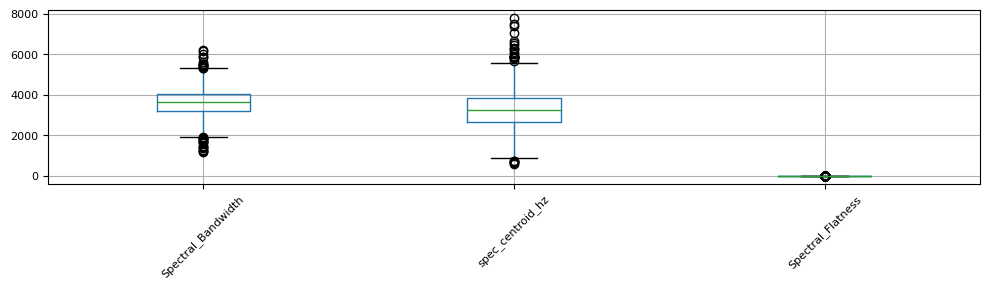

In [27]:
import matplotlib.pyplot as plt

cols_num = [
    
    'rel_year','Spectral_Bandwidth','spec_centroid_hz','Spectral_Flatness'
]

plt.figure(figsize=(10, 3))  # very thin

df[cols_num].boxplot()

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

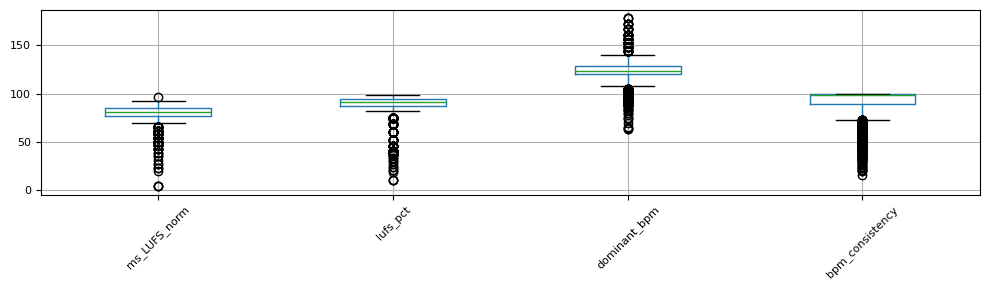

In [28]:
import matplotlib.pyplot as plt

cols_num = [
    'ms_LUFS_norm','lufs_pct',	'dominant_bpm'	,'bpm_consistency',
    'rel_year'
]

plt.figure(figsize=(10, 3))  # very thin

df[cols_num].boxplot()

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

# Pre Process Data for ML model (PCA + Cluster)


1. Energy Dynamics Clusters
ms_lufs, lufs_pct, bpm_consistency, dominant_bpm
Finds: low → peak→ explosive tracks
→ describes movement / intensity over time

2. Energy Texture Clusters 
Spectral_Bandwidth, Spectral_Flatness, spec_centroid_hz
Finds: dark / warm / bright / noisy / clean textures
→ describes frequency character (color of the sound)

3. Sound Energy = Energy Dynamics x Energy Texture Clusters 

## how strong + how it feels

→ Dynamics = how much energy
→ Texture = what kind of energy
→ Sound Energy = full perception


In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. COPY + KEEP COLS
# -----------------------------
cols_keep = ['ID','Path','ms_lufs','lufs_pct','bpm_consistency','dominant_bpm',
             'Spectral_Bandwidth','Spectral_Flatness','spec_centroid_hz',
             'key_dj','genre','rel_year']

df_1 = df[cols_keep].copy()


# -----------------------------
# 2. NUMERICAL CLEAN
# -----------------------------
num_cols = ['ms_lufs','lufs_pct','bpm_consistency','dominant_bpm',
            'Spectral_Bandwidth','Spectral_Flatness','spec_centroid_hz']

df_1[num_cols] = df_1[num_cols].fillna(df_1[num_cols].median())


# -----------------------------
# 3. SCALE NUMERICALS
# -----------------------------
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_1[num_cols]),
    columns=num_cols
)


# # -----------------------------
# # 4. SIMPLE ENCODING
# # -----------------------------
# df_scaled['key_dj_enc'] = df_1['key_dj'].astype('category').cat.codes
# df_scaled['genre_enc'] = df_1['genre'].astype('category').cat.codes


# -----------------------------
# 5. BUILD DYNAMICS DF
# -----------------------------
df_dyn = pd.concat([
    df_1[['ID']],
    df_scaled[['ms_lufs','lufs_pct','bpm_consistency','dominant_bpm']]
], axis=1)

df_dyn['cluster_type'] = 'Dynamics'


# -----------------------------
# 6. BUILD TEXTURE DF
# -----------------------------
df_tex = pd.concat([
    df_1[['ID']],
    df_scaled[['Spectral_Bandwidth','Spectral_Flatness','spec_centroid_hz']]
], axis=1)

df_tex['cluster_type'] = 'Texture'


# -----------------------------
# 7. BUILD COMBINED DF
# -----------------------------
df_comb = pd.concat([
    df_1[['ID']],
    df_scaled
], axis=1)

df_comb['cluster_type'] = 'Combined'

In [30]:
df_comb.head()

,ID,ms_lufs,lufs_pct,bpm_consistency,dominant_bpm,Spectral_Bandwidth,Spectral_Flatness,spec_centroid_hz,cluster_type
0,t1-12306,-0.685017,-0.238195,0.471335,-0.078734,0.282305,-0.333764,0.259544,Combined
1,t1-12300,-0.439335,-0.238195,0.590367,-0.078734,1.691897,1.625490,2.295005,Combined
2,t1-12304,-0.542521,-0.238195,-0.379853,0.189902,-0.933352,-0.553795,-0.673547,Combined
3,t1-12305,-0.363174,0.157205,0.318773,-0.078734,-0.895930,-0.505600,-1.299089,Combined
4,t1-12302,0.513907,0.453756,0.590367,0.189902,-1.184681,-0.723292,-1.285397,Combined


In [31]:
df_comb.head()
df_dyn.head()
df_tex.describe() 

,Spectral_Bandwidth,Spectral_Flatness,spec_centroid_hz
count,2.402000e+03,2.402000e+03,2.402000e+03
mean,3.224361e-16,7.691137e-17,7.395324e-17
std,1.000208e+00,1.000208e+00,1.000208e+00
min,-3.695161e+00,-9.951936e-01,-2.909261e+00
25%,-6.249787e-01,-6.047633e-01,-6.660269e-01
50%,3.447466e-02,-2.731070e-01,-2.020412e-02
75%,6.714749e-01,2.653391e-01,6.297153e-01
max,3.966532e+00,1.064193e+01,4.992892e+00


In [32]:
from sklearn.decomposition import PCA

In [33]:
# -----------------------------
# DYNAMICS PCA
# -----------------------------
X_dyn = df_dyn.drop(columns=['ID','cluster_type'])

pca_dyn = PCA(n_components=2)
dyn_pca_vals = pca_dyn.fit_transform(X_dyn)

df_dyn_pca = df_dyn[['ID']].copy()
df_dyn_pca['PC1'] = dyn_pca_vals[:,0]
df_dyn_pca['PC2'] = dyn_pca_vals[:,1]
df_dyn_pca['cluster_type'] = 'Dynamics'

# -----------------------------
# TEXTURE PCA
# -----------------------------
X_tex = df_tex.drop(columns=['ID','cluster_type'])

pca_tex = PCA(n_components=2)
tex_pca_vals = pca_tex.fit_transform(X_tex)

df_tex_pca = df_tex[['ID']].copy()
df_tex_pca['PC1'] = tex_pca_vals[:,0]
df_tex_pca['PC2'] = tex_pca_vals[:,1]
df_tex_pca['cluster_type'] = 'Texture'

In [34]:
# -----------------------------
# COMBINED PCA = texture + dynamics 
# -----------------------------
X_comb = df_comb.drop(columns=['ID','cluster_type'])

pca_comb = PCA(n_components=3)
comb_pca_vals = pca_comb.fit_transform(X_comb)

df_comb_pca = df_comb[['ID']].copy()
df_comb_pca['PC1'] = comb_pca_vals[:,0]
df_comb_pca['PC2'] = comb_pca_vals[:,1]
df_comb_pca['PC3'] = comb_pca_vals[:,2]
df_comb_pca['cluster_type'] = 'Combined'

df_comb_pca.head()

,ID,PC1,PC2,PC3,cluster_type
0,t1-12306,0.070185,-0.537234,0.101665,Combined
1,t1-12300,3.014754,-1.434392,-0.114497,Combined
2,t1-12304,-1.404152,-0.147575,0.269437,Combined
3,t1-12305,-1.477054,0.382005,0.118969,Combined
4,t1-12302,-1.413336,1.301503,0.351259,Combined


# PCA

In [35]:
df_pca = df_dyn_pca[['ID','PC1','PC2']].rename(columns={'PC1':'dyn_PC1','PC2':'dyn_PC2'})

df_pca = df_pca.merge(
    df_tex_pca[['ID','PC1','PC2']].rename(columns={'PC1':'tex_PC1','PC2':'tex_PC2'}),
    on='ID'
)

df_pca = df_pca.merge(
    df_comb_pca[['ID','PC1','PC2', 'PC3']].rename(columns={'PC1':'comb_PC1','PC2':'comb_PC2','PC3':'comb_PC3'}),
    on='ID'
)

In [36]:
df_pca.head()

,ID,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3
0,t1-12306,-0.540083,0.276343,0.157001,-0.481653,0.070185,-0.537234,0.101665
1,t1-12300,-0.346233,0.298166,3.259165,-0.005337,3.014754,-1.434392,-0.114497
2,t1-12304,-0.596637,0.096674,-1.256782,0.132983,-1.404152,-0.147575,0.269437
3,t1-12305,-0.080498,0.105083,-1.595019,0.327656,-1.477054,0.382005,0.118969
4,t1-12302,0.811467,0.301407,-1.870852,0.268831,-1.413336,1.301503,0.351259


# CLuster -> After applied PCA we got 3 vecotrs from : Energy Dynamics × Energy Texture

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

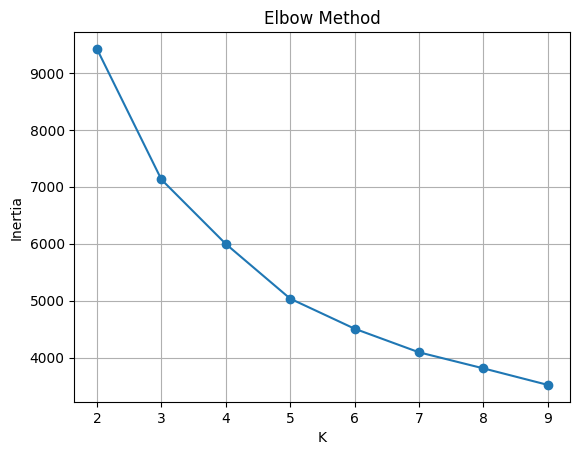

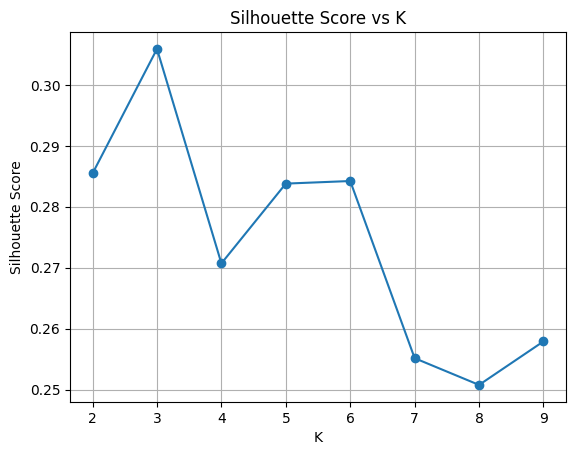

In [38]:
X = df_pca[['comb_PC1','comb_PC2','comb_PC3']]

inertia = []
sil = []

K_range = range(2,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    sil.append(silhouette_score(X, labels))

pd.DataFrame({'k':K_range, 'inertia':inertia, 'silhouette':sil})

import matplotlib.pyplot as plt

# -----------------------------
# ELBOW (INERTIA)
# -----------------------------
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid()
plt.show()


# -----------------------------
# SILHOUETTE
# -----------------------------
plt.figure()
plt.plot(K_range, sil, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.grid()
plt.show()

# 1 Pick number of clusters

In [39]:
k_opt = 4  # (0,1,2,3)  # or 5 depending on your plots

# 2 Fit Model

In [40]:
from sklearn.cluster import KMeans

# -----------------------------
# 1. FIT CLUSTERS (COMBINED)
# -----------------------------
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)

df_pca['cluster'] = kmeans.fit_predict(
    df_pca[['comb_PC1','comb_PC2','comb_PC3']]
)


# -----------------------------
# 2. ORDER CLUSTERS (LOW → HIGH ENERGY)
# -----------------------------
cluster_order = (
    df_pca.groupby('cluster')['comb_PC1']
    .mean()
    .sort_values()
    .index
)

mapping = {old: i for i, old in enumerate(cluster_order)}

df_pca['cluster_ord'] = df_pca['cluster'].map(mapping)


# -----------------------------
# 3. LABEL CLUSTERS (SAFE)
# -----------------------------
labels = {
    0: 'deep',
    1: 'groovy',
    2: 'driving',
    3: 'peak',
}

df_pca['cluster_name'] = df_pca['cluster_ord'].map(labels).fillna('extra')



In [41]:
df_pca.head()

,ID,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3,cluster,cluster_ord,cluster_name
0,t1-12306,-0.540083,0.276343,0.157001,-0.481653,0.070185,-0.537234,0.101665,0,2,driving
1,t1-12300,-0.346233,0.298166,3.259165,-0.005337,3.014754,-1.434392,-0.114497,2,3,peak
2,t1-12304,-0.596637,0.096674,-1.256782,0.132983,-1.404152,-0.147575,0.269437,1,1,groovy
3,t1-12305,-0.080498,0.105083,-1.595019,0.327656,-1.477054,0.382005,0.118969,1,1,groovy
4,t1-12302,0.811467,0.301407,-1.870852,0.268831,-1.413336,1.301503,0.351259,1,1,groovy


# VIZUALIZE 

In [42]:
df_pca['cluster_label'] = (
    df_pca['cluster_ord'].astype(str) + '_' + df_pca['cluster_name']
)

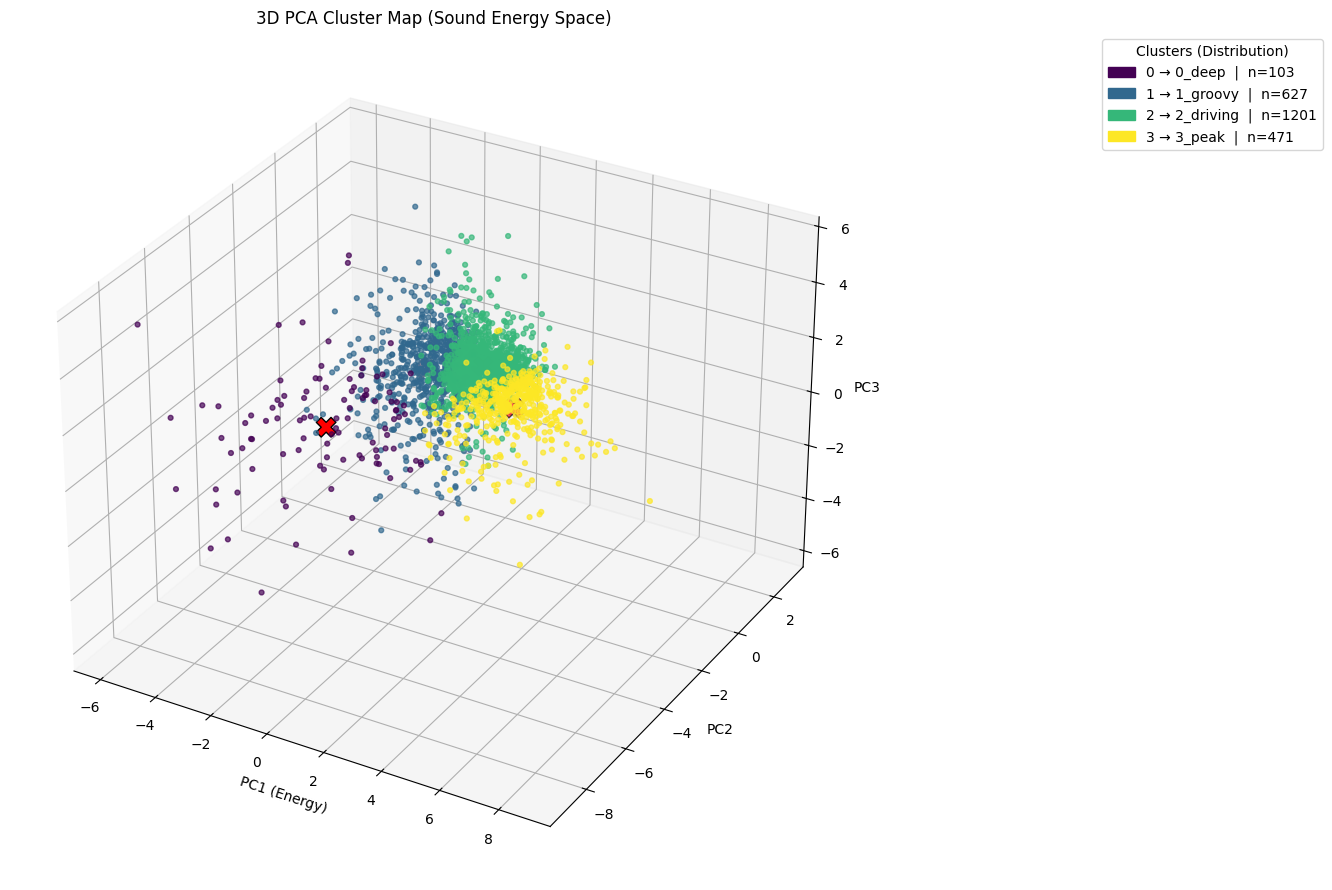

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------
# UNIQUE CLUSTERS + COLORS
# -----------------------------
clusters = sorted(df_pca['cluster_ord'].unique())
cmap = plt.cm.viridis
norm = plt.Normalize(min(clusters), max(clusters))
cluster_colors = {c: cmap(norm(c)) for c in clusters}

# -----------------------------
# SCATTER
# -----------------------------
colors = df_pca['cluster_ord'].map(cluster_colors)

ax.scatter(
    df_pca['comb_PC1'],
    df_pca['comb_PC2'],
    df_pca['comb_PC3'],
    c=colors,
    s=12,
    alpha=0.7
)

# -----------------------------
# CENTROIDS
# -----------------------------
centroids = df_pca.groupby('cluster_ord')[['comb_PC1','comb_PC2','comb_PC3']].mean()

ax.scatter(
    centroids['comb_PC1'],
    centroids['comb_PC2'],
    centroids['comb_PC3'],
    c='red',
    s=200,
    marker='X',
    edgecolor='black'
)

# -----------------------------
# DISTRIBUTION COUNTS ✅
# -----------------------------
cluster_counts = df_pca['cluster_ord'].value_counts().sort_index()

# -----------------------------
# LEGEND DATA
# -----------------------------
legend_df = (
    df_pca[['cluster_ord','cluster_label']]
    .drop_duplicates()
    .sort_values('cluster_ord')
)

legend_handles = []

for _, row in legend_df.iterrows():
    c = row['cluster_ord']
    label = row['cluster_label']
    count = cluster_counts.get(c, 0)
    
    patch = mpatches.Patch(
        color=cluster_colors[c],
        label=f"{c} → {label}  |  n={count}"
    )
    legend_handles.append(patch)

# -----------------------------
# LEGEND
# -----------------------------
ax.legend(
    handles=legend_handles,
    title="Clusters (Distribution)",
    bbox_to_anchor=(1.28, 1),
    loc='upper left'
)

# -----------------------------
# AXES
# -----------------------------
ax.set_xlabel('PC1 (Energy)')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.title('3D PCA Cluster Map (Sound Energy Space)')

plt.tight_layout()
plt.show()

In [49]:
len(df_pca)

2402

# merge back in 

In [51]:
len(df_raw) len(df_pca)

2402

In [52]:
df_all =  df_raw.merge(df_pca, on='ID', how='inner')

In [53]:
df_all.head()

,ID,Path,Extension,dur_seconds,dur_min,sr,bit_depth,channels,file_size,file_size_human,num_frames,ms_lufs,id_cat_lufs,mean_bpm,std_bpm,min_bpm,max_bpm,variation_percentage,dominant_bpm,bpm_consistency,bpm_consistency_cat,title,title_file,artist,artist_file,LABEL,label_file,genre,genre_file,rel_year,rel_year_file,KEY,key_file,mix_name,remixer,remix,date_purchased,rel_date,rel_date_file,key_dj,key_music,Relative_Key,Key_Up,Key_Down,Jaw_s_Mix,Mood_Shifter,comment,ms_LUFS_norm,Spectral_Bandwidth,Spectral_Flatness,HEX_shape_texture,spec_centroid_hz,centroid_color,centroid_desc,year_written_id3,bought_year,lufs_pct,audio_hash,__source_file,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3,cluster,cluster_ord,cluster_name,cluster_label,color
0,t1-12306,/Users/yerik/Music/_1_NEW_SOURCE/_2026_this/__26_01_Mini_VOCAL/dylu_0T[26]-123BPM-9A_Emin--id_t1-12306---Deep-PHONOGRAM--by--RICKWADE-functionalanger(O)-2025.aiff,.aiff,393.799206,6.56332,44100,16,2,70378472,67.12 MB,17366545,-11.530,T,123.426649,2.764799e+00,123.046875,143.554688,2.240034e+00,123,98.148148,D_0,Functional Anger Original Mix,ID3TAGS,Rick Wade,ID3TAGS,Phonogramme,ID3TAGS,Deep House,ID3TAGS,2025,ID3TAGS,Emin,ID3TAGS,Original_Mix,Original Mix,O,2026-01-23,2025-11-10,ID3TAGS,9A,Emin,9B,10A,8A,4A,12B,0LUFS--T-87%--0Emin_123BPM--id_t1-12306,76.923077,3800.914308,0.008291,#005EFF,3490.022323,#808000,"Tense, decaying",Unsupported,2026,87,622ea4787b16ecd93da93d52c6febda8c780942622aff84b45584ff2c29fc0cf,df_t6t_final.pkl,-0.540083,0.276343,0.157001,-0.481653,0.070185,-0.537234,0.101665,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)"
1,t1-12300,/Users/yerik/Music/_1_NEW_SOURCE/_2026_this/__26_01_Mini_VOCAL/dylu_0T[26]-123BPM-6A_Gmin--id_t1-12300---Deep-CDR(CROS--by--AARONCARLDYED-nakedfeataaron(O)-2009.aiff,.aiff,469.746667,7.829111,44100,16,2,82900338,79.06 MB,20715828,-11.030,T,123.046875,0.000000e+00,123.046875,123.046875,0.000000e+00,123,100.000000,D_0,Naked feat Aaron Carl Original Mix,ID3TAGS,Aaron Carl Dyed Soundorom,ID3TAGS,CDR (Crosstown Digital Rebels),ID3TAGS,Deep House,ID3TAGS,2009,ID3TAGS,Gmin,ID3TAGS,Original_Mix,Original Mix,O,2026-01-23,2009-01-26,ID3TAGS,6A,Gmin,6B,7A,5A,1A,9B,0LUFS--T-87%--0Gmin_123BPM--id_t1-12300,76.923077,4725.746003,0.032783,#113C70,5344.390429,#FFFF99,Dreamy & bright,Unsupported,2026,87,71888cd188d034fc921f1b4d8e4bc3961373e5815f4cc72c4dd1c7a49fe01f45,df_t6t_final.pkl,-0.346233,0.298166,3.259165,-0.005337,3.014754,-1.434392,-0.114497,2,3,peak,3_peak,"(0.993248, 0.906157, 0.143936, 1.0)"
2,t1-12304,/Users/yerik/Music/_1_NEW_SOURCE/_2026_this/__26_01_Mini_VOCAL/dylu_6T[26]-126BPM-7B_Fmaj--id_t1-12304---Deep-CDR(CROS--by--DYEDSOUNDOROM-beautifulevaor(O)-2009.aiff,.aiff,386.573333,6.442889,44100,16,2,68222900,65.06 MB,17047884,-11.240,T,119.603689,1.528407e+01,83.354335,126.048018,1.277893e+01,126,84.905660,D_6,Beautiful Eva Original Mix,ID3TAGS,Dyed Soundorom,ID3TAGS,CDR (Crosstown Digital Rebels),ID3TAGS,Deep House,ID3TAGS,2009,ID3TAGS,Fmaj,ID3TAGS,Original_Mix,Original Mix,O,2026-01-23,2009-01-26,ID3TAGS,7B,Fmaj,7A,8B,6B,2B,4A,6LUFS--T-87%--6Fmaj_126BPM--id_t1-12304,76.923077,3003.322452,0.005540,#005EFF,2639.947662,#3C3B6E,Dubby twilight,Unsupported,2026,87,ed45bd1d38502a22a69f1adff5870f477195eb67336f4e65c71bf295e105caa4,df_t6t_final.pkl,-0.596637,0.096674,-1.256782,0.132983,-1.404152,-0.147575,0.269437,1,1,groovy,1_groovy,"(0.190631, 0.407061, 0.556089, 1.0)"
3,t1-12305,/Users/yerik/Music/_1_NEW_SOURCE/_2026_this/__26_01_Mini_VOCAL/dylu_1U[26]-123BPM-8B_Cmaj--id_t1-12305---Tech-GETPHYSI--by--PEZZNER-iamyoudjtre(R)-2025.aiff,.aiff,520.718345,8.678639,44100,16,2,91939102,87.68 MB,22963679,-10.875,U,121.242972,9.107006e+00,61.523438,123.046875,7.511369e+00,123,95.774648,D_1,I Am You DJ T Remix,ID3TAGS,Pezzner,ID3TAGS,Get Physical Music,ID3TAGS,Tech House,ID3TAGS,2025,ID3TAGS,Cmaj,ID3TAGS,DJ_T._Remix,DJ T. Remix DJ T.,R,2026-01-23,2025-04-10,ID3TAGS,8B,Cmaj,8A,9B,7B,3B,5A,1LUFS--U-91%--1Cmaj_123BPM--id_t1-12305,80.769231,3027.

<Axes: xlabel='cluster_ord'>

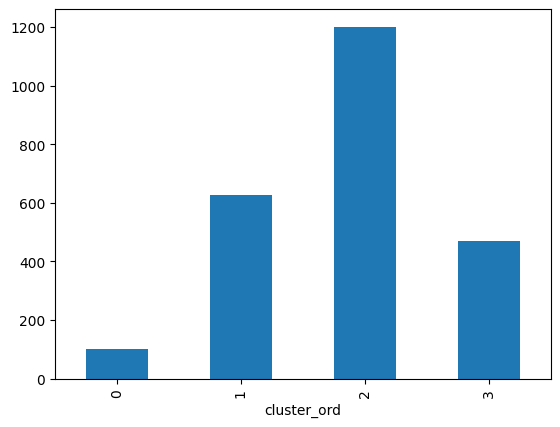

In [55]:
df_all['cluster_ord'].value_counts().sort_index().plot(kind='bar')

# CHECK SOME VARIABLES 

In [68]:
pivot = (
    df_all.groupby(['cluster_ord','id_cat_lufs'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # sort LUFS categories
)
pivot

id_cat_lufs,A,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y
cluster_ord,,,,,,,,,,,,,,,,,,,,,,
0,3,1,2,2,1,2,2,5,6,13,10,14,15,24,3,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,40,63,157,172,134,52,8,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,37,117,331,435,234,41,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,7,17,34,78,136,125,68,6,0


In [69]:
pivot = (
    df_all.groupby(['cluster_ord','genre'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # genre
)
pivot

genre,,Abstract,Acapella,Acid,"Acid, House",Afro House,Afro House,Afro Latin / Electronic,Afro Tribal,AfroLatin,Amapiano,Bass Club,Bass / Club,Bass / Cumbia,Bass House,Bass House,Blues,Booty,Breakbeat / Bass,Breaks Breakbeat UK Bass,Breaks / Breakbeat / UK Bass,COO:US##G:ghetto tech##G:ghettotech##G:ghetto house##G:chicago house##G:house#,Classic House,DJ Tools,Dance,Dance,Dance Pop,Dance / Electro Pop,Dance / Pop,Deep / Soulful House,Deep Dubstep / Grime,Deep House,Deep House,Detroit Classics,Detroit House,Detroit-Deep-House,Detroit-House,DetroitHouse,Disko Punk,Downtempo,Drum & Bass,Drum & Bass,Dubstep,Dubstep,Electro,Electro (Classic / Detroit / Modern),Electro / Breaks,Electro House,Electronic,Electronic,Electronic / Cumbia,Electronic / Electro / Techno / House,Electronic / Tropical,"Electronic, Indige",Electronica,Electronica,Folktronica,Funky House,Funky House,Ghettotech,Global Bass / Afro-Colombian,Gtech Latin,"HOUSE, TECH HOUSE",Hard Dance,Hard Dance,Hard Dance / Hardcore,Hard Dance / Hardcore / Neo Rave,Hard Drum,Hard Techno,Hip-Hop/Rap,House,House,India-mapaiano,Indie Dance,Indie Dance,Jackin House,Jazz Funk,Latin,Latin,Latin House,Latin House,Mainstage,Mainstage,Melodic House & Techno,Melodic House & Techno,Mexican House,Minimal Deep Tech,Minimal / Deep Tech,None,Nu Disco / Disco,Organic House,Organic House,Organic House Downtempo,Organic House / Downtempo,Progressive House,Progressive House,"Psychill, Downtempo",Ragaeton,Reggaeton,Reggaeton,Reggaeton-Gtech,Rgtton Gtech Latin,Salsa,Tech House,Tech House,Techno,Techno (Peak Time Driving),Techno (Peak Time / Driving),Techno (Raw Deep Hypnotic),Techno (Raw / Deep / Hypnotic),Techno - Que,Techno/Minimal/Experimental,Top 40,Trance,Trance (Main Floor),Trance (Main Floor),Trance (Raw / Deep / Hypnotic),Trap / Future Bass,Trap / Hip-Hop / R&B,Trap / Wave,Tribal Bass,Tribal Latin,Tribal-MainStage,UK Garage Bassline,UK Garage / Bassline,Various,World / Latin,s House,vogue
cluster_ord,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,1,0,2,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,3,0,7,0,0,1,3,4,0,0,6,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,3,0,0,0,0,0,7,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,11,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,13,0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,4,0,3,3,0,0,2,0,0,0,1,1,0,0,0,0,0,0,2,0,0,0
1,0,1,0,0,0,9,3,0,0,0,0,1,15,1,1,1,0,7,1,0,6,0,0,5,0,0,1,4,11,0,0,82,1,2,2,4,1,0,0,4,2,0,1,0,1,4,0,0,10,0,2,1,1,0,54,12,1,1,0,0,0,2,0,0,0,1,1,0,0,0,92,5,1,16,0,1,6,0,2,1,0,0,1,11,1,2,0,23,4,23,1,7,4,11,0,0,1,3,1,0,3,1,9,24,3,12,0,29,1,8,0,1,1,0,0,0,0,7,1,6,0,0,0,0,1,0,1,0,1
2,1,0,0,0,1,47,10,1,3,2,1,3,19,0,2,5,1,4,0,1,15,0,2,1,1,0,4,12,16,1,2,156,5,0,3,3,1,1,0,0,5,1,0,1,0,6,1,0,3,0,1,0,0,1,51,8,0,10,2,0,1,0,1,1,1,0,0,2,1,1,229,12,2,42,1,12,4,1,10,0,1,4,1,18,6,0,2,45,22,42,1,3,3,4,3,2,0,2,0,4,14,1,0,86,18,19,1,53,0,19,1,0,1,0,1,1,2,2,1,4,1,1,0,1,5,0,0,1,0
3,0,0,0,0,0,16,1,0,10,0,2,0,5,0,0,1,0,0,0,1,5,0,0,5,0,1,3,5,7,0,2,83,0,0,0,0,1,0,1,0,3,0,0,0,0,1,0,1,1,1,0,0,0,0,11,1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,114,4,0,11,1,10,0,0,2,0,0,3,0,4,1,4,0,6,8,22,0,2,0,1,1,0,0,0,0,0,0,0,1,46,6,4,0,16,0,3,0,0,1,0,1,0,0,1,0,0,0,0,2,0,2,0,0,1,0


In [74]:
pivot = (
    df_all.groupby(['cluster_ord','dominant_bpm'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # BPM
)
pivot

dominant_bpm,63,64,65,69,74,75,78,80,83,85,86,88,89,91,92,94,96,98,99,101,103,105,108,110,112,115,117,120,123,126,129,133,136,140,144,148,152,157,161,167,172,178
cluster_ord,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,2,0,1,0,3,1,1,0,1,3,3,0,4,14,16,17,18,2,4,1,1,2,3,0,0,1,0,2
1,1,1,0,1,1,1,1,2,4,1,2,4,3,9,6,3,6,8,11,10,14,16,15,15,19,23,29,91,115,95,39,23,13,17,7,3,7,5,3,2,1,0
2,0,0,0,0,0,0,0,0,0,0,0,2,1,1,1,1,0,2,3,3,3,1,2,10,7,15,34,143,294,299,193,56,45,32,19,5,6,6,10,3,3,1
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,4,1,3,0,0,3,2,4,8,14,16,73,131,116,62,17,3,5,2,0,0,1,2,0,1,0


In [76]:
pivot = (
    df_all.groupby(['cluster_ord','bpm_consistency_cat'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # BPM consitency CAT
)
pivot

bpm_consistency_cat,D_0,D_1,D_3,D_6,D_9
cluster_ord,,,,,
0,39,7,16,24,17
1,206,71,115,189,46
2,684,144,223,134,16
3,320,37,67,40,7


In [77]:
pivot = (
    df_all.groupby(['cluster_ord','rel_year'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # rel YEAR
)
pivot

rel_year,1977,1979,1980,1986,1990,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
cluster_ord,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,1,1,0,0,0,1,1,1,2,3,2,0,0,0,1,0,2,1,1,3,5,1,0,4,4,2,0,2,1,2,3,6,6,7,17,1
1,0,0,2,1,0,0,0,0,3,1,0,1,1,2,1,0,1,4,0,1,9,6,10,11,9,10,31,25,23,12,36,37,37,35,29,45,63,77,42
2,1,1,0,0,0,1,1,1,0,1,1,1,2,0,1,2,2,1,4,2,7,5,18,26,20,26,46,30,23,28,71,43,60,64,75,115,132,178,122
3,0,0,0,0,0,1,1,0,0,2,1,1,2,2,1,1,2,4,0,6,6,5,5,9,8,22,20,21,13,12,37,22,19,18,21,42,56,58,39


In [80]:
pivot = (
    df_all.groupby(['cluster_ord','key_music'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # rel YEAR
)
pivot

key_music,A#maj,A#min,Amaj,Amin,Bmaj,Bmin,C#maj,C#min,Cmaj,Cmin,D#maj,D#min,Dmaj,Dmin,Emaj,Emin,F#maj,F#min,Fmaj,Fmin,G#maj,G#min,Gmaj,Gmin
cluster_ord,,,,,,,,,,,,,,,,,,,,,,,,
0,2,7,2,4,3,3,1,4,4,4,3,4,5,3,2,10,0,5,0,9,1,8,4,15
1,11,15,12,56,10,12,13,21,22,29,7,15,30,36,14,36,8,41,25,41,18,44,29,82
2,13,45,34,89,9,23,27,26,43,43,45,39,35,56,29,67,17,100,21,105,33,86,51,165
3,6,11,8,42,6,14,9,10,18,15,14,10,18,29,10,35,11,44,14,43,11,26,12,55


In [81]:
pivot = (
    df_all.groupby(['cluster_ord','remix'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # rel YEAR
)
pivot

remix,E,O,R,U
cluster_ord,,,,
0,0,78,5,20
1,13,476,84,54
2,90,786,208,117
3,41,275,80,75


In [82]:
pivot = (
    df_all.groupby(['cluster_ord','centroid_desc'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # rel YEAR
)
pivot

centroid_desc,Airy textures,"Ancient, dirty glow","Assertive, bright",Creeping psychedelia,Dramatic & haunting,Dreamy & bright,Dubby twilight,Emotional but soft,Emotional climax,"Harsh, clinical, hyper-bright",Heated drama,Heavy melancholy,Hollow & ghostly,Industrial minimal,"Intense, emotional","Jungle, tribal pulse",Muted emotion,"Organic, earthy","Raw, gritty tension",Sparkling energy,"Submerged, thick textures","Tense, decaying"
cluster_ord,,,,,,,,,,,,,,,,,,,,,,
0,0,7,3,11,4,0,7,4,1,1,4,5,0,1,6,15,9,9,6,0,1,9
1,0,6,0,131,31,0,93,0,0,0,1,101,3,13,81,59,1,39,51,0,4,13
2,0,209,2,32,0,0,91,0,16,0,55,8,0,0,1,171,141,249,0,0,0,226
3,31,26,73,0,0,15,0,44,87,19,94,0,0,0,0,1,69,0,0,5,0,7


# texture and shape 

In [130]:
# HEX → label dictionary
hex_map = {
    '#ADD8FF': 'subby_low_focus',
    '#3EA4FF': 'lower_groove',
    '#005EFF': 'core_groove',
    '#113C70': 'highs_tribal',
    '#000B2D': 'sparkly_shimmer',
    '#FFE8CF': 'soft_noise',
    '#FFC78C': 'noisy_groove',
    '#FFA64F': 'bright_distortion',
    '#FF7600': 'high_crackle',
    '#C84200': 'harsh_sparkle'
}

# create new column
df_all['shape_texture_label'] = df['HEX_shape_texture'].map(hex_map)

In [131]:
pivot = (
    df_all.groupby(['cluster_ord','shape_texture_label'])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)   # rel YEAR
)
pivot

shape_texture_label,bright_distortion,core_groove,harsh_sparkle,high_crackle,highs_tribal,lower_groove,soft_noise,sparkly_shimmer,subby_low_focus
cluster_ord,,,,,,,,,
0,2,60,0,0,13,22,1,0,5
1,0,280,0,0,1,328,0,0,18
2,0,1109,0,0,70,22,0,0,0
3,1,131,1,2,316,0,0,20,0


In [374]:
#df_all.head(40)

# classify new song into a cluster 

In [437]:
input_id = 't1-8280o'
row = df_all[df_all['ID'] == input_id].iloc[0]

In [438]:
# get cluster input 
cluster = row['cluster_ord']
cluster_label = row['cluster_label']
cluster_label 

'2_driving'

In [439]:
# FILTER SAME CLUSTER (candidate pool)
df_pool = df_all[df_all['cluster_ord'] == cluster].copy()
len(df_pool)

1201

In [440]:
# REMOVE SAME SONG
df_pool = df_pool[df_pool['ID'] != input_id]

# RULES TO MATCH SONG

In [446]:
# --------------------------------------------------
# BPM MATCHING STRATEGY (CRITICAL FOR DJ FLOW)
# --------------------------------------------------
# Logic:
# 1. Try exact BPM match (±0)
# 2. If not enough songs → expand to ±1
# 3. If still not enough → expand to ±2
#
# This ensures:
# → tight mixing first
# → avoids unnecessary tempo jumps
# → controlled fallback when pool is small
# --------------------------------------------------

target_bpm = row['dominant_bpm']

# STEP 1 → exact match
df_bpm = df_pool[
    (df_pool['dominant_bpm'] >= target_bpm) &
    (df_pool['dominant_bpm'] <= target_bpm)
]

# STEP 2 → expand ±1 if needed
if len(df_bpm) < 5:
    df_bpm = df_pool[
        (df_pool['dominant_bpm'] >= target_bpm - 1) &
        (df_pool['dominant_bpm'] <= target_bpm + 1)
    ]

# STEP 3 → expand ±2 if still not enough
if len(df_bpm) < 5:
    df_bpm = df_pool[
        (df_pool['dominant_bpm'] >= target_bpm - 2) &
        (df_pool['dominant_bpm'] <= target_bpm + 2)
    ]
    
df_bpm['dominant_bpm'].head()

# IMPORTANT 
df_pool = df_bpm.copy()
df_pool[['ID','dominant_bpm','key_dj']]


,ID,dominant_bpm,key_dj
194,t1-3603,152,3A
480,t12-580p,152,1A
753,t33-5806,152,6A
1522,t5-102700,152,1A
2193,t28-582e,152,4A


In [442]:
# --------------------------------------------------
# KEY MATCHING (EXTENDED DJ ENGINE)
# --------------------------------------------------
# Order of priority:
# 1. Relative_Key   → best blend
# 2. Same key_dj    → stable
# 3. Jaw_s_Mix      → advanced harmonic system
# 4. Mood_Shifter   → emotional transition
# 5. Key_Up         → energy lift
# 6. Key_Down       → energy release
#
# → ACCUMULATE results (never overwrite)
# --------------------------------------------------
#### here we can have an LLM that talks to this set of variables 
# energy up/down same energy key or mood change or jaw key 
min_candidates = 30

rel_key   = row['Relative_Key']
same_key  = row['key_dj']
jaw_key   = row['Jaw_s_Mix']
mood_key  = row['Mood_Shifter']
key_up    = row['Key_Up']
key_down  = row['Key_Down']

# STEP 1 → Relative Key
df_key = df_pool[df_pool['key_dj'] == rel_key]

# STEP 2 → SAME key
if len(df_key) < min_candidates:
    df_key = pd.concat([
        df_key,
        df_pool[df_pool['key_dj'] == same_key]
    ]).drop_duplicates()

# STEP 3 → Jaw_s_Mix
if len(df_key) < min_candidates:
    df_key = pd.concat([
        df_key,
        df_pool[df_pool['key_dj'] == jaw_key]
    ]).drop_duplicates()

# STEP 4 → Mood_Shifter
if len(df_key) < min_candidates:
    df_key = pd.concat([
        df_key,
        df_pool[df_pool['key_dj'] == mood_key]
    ]).drop_duplicates()

# STEP 5 → Key Up
if len(df_key) < min_candidates:
    df_key = pd.concat([
        df_key,
        df_pool[df_pool['key_dj'] == key_up]
    ]).drop_duplicates()

# STEP 6 → Key Down
if len(df_key) < min_candidates:
    df_key = pd.concat([
        df_key,
        df_pool[df_pool['key_dj'] == key_down]
    ]).drop_duplicates()

# break control 

In [443]:
def _check_key_pool(df_key, min_rows=5):
    return 'stop' if len(df_key) < min_rows else 'next'

break_key = _check_key_pool(df_key)
break_key

'stop'

# if stop pick first here 

In [444]:
df_key

,ID,Path,Extension,dur_seconds,dur_min,sr,bit_depth,channels,file_size,file_size_human,num_frames,ms_lufs,id_cat_lufs,mean_bpm,std_bpm,min_bpm,max_bpm,variation_percentage,dominant_bpm,bpm_consistency,bpm_consistency_cat,title,title_file,artist,artist_file,LABEL,label_file,genre,genre_file,rel_year,rel_year_file,KEY,key_file,mix_name,remixer,remix,date_purchased,rel_date,rel_date_file,key_dj,key_music,Relative_Key,Key_Up,Key_Down,Jaw_s_Mix,Mood_Shifter,comment,ms_LUFS_norm,Spectral_Bandwidth,Spectral_Flatness,HEX_shape_texture,spec_centroid_hz,centroid_color,centroid_desc,year_written_id3,bought_year,lufs_pct,audio_hash,__source_file,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3,cluster,cluster_ord,cluster_name,cluster_label,color,shape_texture_label
480,t12-580p,/Users/yerik/Music/_1_NEW_SOURCE/_2023_this/_23_05_AN_bigPINK/dylu_6V[23]-152BPM-1A_G#min--id_t12-580p---Hard-THEACID--by--LENOIZE-bornslippy(O)-2022.aiff,.aiff,257.7,4.295,44100,16,2,45458334,43.35 MB,11364570,-9.577,V,136.070595,22.567135,99.384014,151.999081,16.584873,152,51.428571,D_6,Born Slippy,FILE_NAME,Lenoize,FILE_NAME,The Acid Mind Recordings,FILE_NAME,Hard Techno,FILE_NAME,2022,FILE_NAME,G#min,FILE_NAME,Original_Mix,Original Mix,O,2023-05-22,2022-12-24,FILE_NAME,1A,G#min,1B,2A,12A,8A,4B,6LUFS--V-94%--6G#min_152BPM--id_t12-580p,84.615385,3445.624183,0.007950,#005EFF,2999.043766,#014421,"Jungle, tribal pulse",Unsupported,2023,94,2d9252148c54b27a31ee7859732e874a4e6edf48f8943449dffebb79b7b8ea0e,df_2556t_final.pkl,0.226754,0.906300,-0.512374,-0.114105,-0.709516,0.533241,1.838935,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",core_groove
1522,t5-102700,/Users/yerik/Music/_1_NEW_SOURCE/_2025_this/__25_10_zBCA_GuaraBrazil/dylu_6V[25]-152BPM-1A_G#min--id_t5-102700---Regg-SELFRELE--by--DJGUARI-daddyyankeesh(O)-.aiff,.aiff,190.360544,3.172676,44100,16,2,33622866,32.07 MB,8394900,-8.556,V,150.956801,1.854750,147.656250,151.999081,1.228663,152,76.000000,D_6,Daddy Yankee s Hard Techno,ID3TAGS,DJ Guari,ID3TAGS,Self Release,FILE_NAME,Reggaeton-Gtech,FILE_NAME,NaN,ID3TAGS,G#min,FILE_NAME,Original Mix,Original Mix,O,2025-10-27,None,FILE_NAME,1A,G#min,1B,2A,12A,8A,4B,6LUFS--V-94%--6G#min_152BPM--id_t5-102700,84.615385,3305.872927,0.005104,#005EFF,3190.538148,#556B2F,"Organic, earthy",Skipped,2025,94,5327260e398c8b43f88b8d37567a308627394bde37e512c41993af74c96020b7,df_bcat_final.pkl,0.909976,1.567489,-0.627025,-0.269051,-0.364885,1.121741,2.151742,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",core_groove


In [425]:
df_pool = df_key.copy()

### here we can use an LLM to know if we want complete shift in energy key up or down or comeplete shift 

In [427]:
# --------------------------------------------------
# FINAL RANKING → TEXTURE + DYNAMICS PROXIMITY
# --------------------------------------------------
# Variables priority:
# 1. spec_centroid_hz   → brightness / tonal focus
# 2. Spectral_Bandwidth → width / fullness
# 3. Spectral_Flatness  → tonal vs noisy
# 4. ms_LUFS_norm       → energy level
#
# Goal:
# → find songs CLOSEST to input song
# --------------------------------------------------

if break_key == 'next':

    # reference values (input song)
    ref_centroid = row['spec_centroid_hz']
    ref_bw       = row['Spectral_Bandwidth']
    ref_flat     = row['Spectral_Flatness']
    ref_lufs     = row['ms_LUFS_norm']

    # compute absolute distances
    df_pool['d_centroid'] = (df_pool['spec_centroid_hz'] - ref_centroid).abs()
    df_pool['d_bw']       = (df_pool['Spectral_Bandwidth'] - ref_bw).abs()
    df_pool['d_flat']     = (df_pool['Spectral_Flatness'] - ref_flat).abs()
    df_pool['d_lufs']     = (df_pool['ms_LUFS_norm'] - ref_lufs).abs()

    # --------------------------------------------------
    # NORMALIZE (IMPORTANT → make comparable scales)
    # --------------------------------------------------
    for col in ['d_centroid','d_bw','d_flat','d_lufs']:
        df_pool[col] = df_pool[col] / df_pool[col].max()

    # --------------------------------------------------
    # WEIGHTED SCORE (ORDER MATTERS)
    # --------------------------------------------------
    df_pool['score'] = (
        df_pool['d_centroid'] * 4 +
        df_pool['d_bw']       * 3 +
        df_pool['d_flat']     * 2 +
        df_pool['d_lufs']     * 1
    )

    # lower score = better match
    df_next = df_pool.sort_values('score').head(10)

In [428]:
len(df_next)

10

In [429]:
# --------------------------------------------------
# FINAL PICK LOGIC (POST-RANKING)
# --------------------------------------------------
# Input: df_next (already sorted by best match)
#
# Priority:
# 1. Relative_Key
# 2. Key_Up
# 3. Same key
#
# If no matches at all → fallback to top ranked
# --------------------------------------------------


rel_key  = row['Relative_Key']
key_up   = row['Key_Up']
same_key = row['key_dj']

# STEP 1 → Relative Key
df_rel = df_next[df_next['key_dj'] == rel_key]

if len(df_rel) > 0:
    best_song_df = df_rel.head(1)

else:
    # STEP 2 → Key Up
    df_up = df_next[df_next['key_dj'] == key_up]

    if len(df_up) > 0:
        best_song_df = df_up.head(1)

    else:
        # STEP 3 → Same Key
        df_same = df_next[df_next['key_dj'] == same_key]

        if len(df_same) > 0:
            best_song_df = df_same.head(1)

        else:
            # FINAL FALLBACK
            best_song_df = df_next.head(1)

In [430]:
best_song_df

,ID,Path,Extension,dur_seconds,dur_min,sr,bit_depth,channels,file_size,file_size_human,num_frames,ms_lufs,id_cat_lufs,mean_bpm,std_bpm,min_bpm,max_bpm,variation_percentage,dominant_bpm,bpm_consistency,bpm_consistency_cat,title,title_file,artist,artist_file,LABEL,label_file,genre,genre_file,rel_year,rel_year_file,KEY,key_file,mix_name,remixer,remix,date_purchased,rel_date,rel_date_file,key_dj,key_music,Relative_Key,Key_Up,Key_Down,Jaw_s_Mix,Mood_Shifter,comment,ms_LUFS_norm,Spectral_Bandwidth,Spectral_Flatness,HEX_shape_texture,spec_centroid_hz,centroid_color,centroid_desc,year_written_id3,bought_year,lufs_pct,audio_hash,__source_file,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3,cluster,cluster_ord,cluster_name,cluster_label,color,shape_texture_label,d_centroid,d_bw,d_flat,d_lufs,score
1316,t39-5806,/Users/yerik/Music/_1_NEW_SOURCE/_2025_this/__25_02_CDMX_SecretoRoom/dylu_6V[25]-129BPM-1B_Bmaj--id_t39-5806----HOUSEHER--by--DJCHRISDIABLO-1djchrisdiabl(O)-2022.aiff,.aiff,590.28,9.838,44100,16,2,104125544,99.30 MB,26031348,-9.643,V,127.544359,6.198343,95.703125,135.999178,4.859755,129,79.012346,D_6,1 Dj Chris Diablo HOUS,FILE_NAME,Dj Chris Diablo,FILE_NAME,HOUSE HEROES,FILE_NAME,None,FILE_NAME,2022,FILE_NAME,Bmaj,FILE_NAME,original,original,O,2025-05-06,2022-01-01,FILE_NAME,1B,Bmaj,1A,2B,12B,8B,10A,6LUFS--V-94%--6Bmaj_129BPM--id_t39-5806,84.615385,3643.779401,0.006536,#005EFF,4052.686414,#FF7034,Heated drama,Unsupported,2025,94,60d6975ec9c79130147cbbadc90956cd65d92c110d750a50ea8ecce69ce9f695,df_2556t_final.pkl,0.364179,-0.052172,0.32231,-0.661588,0.331514,0.3749,0.193453,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",core_groove,0.075901,0.362796,0.022207,0.0,1.436407


In [431]:
# --------------------------------------------------
# BUILD FINAL DF → CURRENT + BEST MATCH
# --------------------------------------------------

# current song → keep as DF
current_df = df_all[df_all['ID'] == input_id].head(1)

# best match already as DF → best_song_df

# combine both
df_pair = pd.concat([current_df, best_song_df]).reset_index(drop=True)

In [432]:
df_pair['role'] = ['current', 'next']
df_pair[['title','dominant_bpm']]

,title,dominant_bpm
0,Born Slippy,152
1,1 Dj Chris Diablo HOUS,129


In [433]:
df_next

,ID,Path,Extension,dur_seconds,dur_min,sr,bit_depth,channels,file_size,file_size_human,num_frames,ms_lufs,id_cat_lufs,mean_bpm,std_bpm,min_bpm,max_bpm,variation_percentage,dominant_bpm,bpm_consistency,bpm_consistency_cat,title,title_file,artist,artist_file,LABEL,label_file,genre,genre_file,rel_year,rel_year_file,KEY,key_file,mix_name,remixer,remix,date_purchased,rel_date,rel_date_file,key_dj,key_music,Relative_Key,Key_Up,Key_Down,Jaw_s_Mix,Mood_Shifter,comment,ms_LUFS_norm,Spectral_Bandwidth,Spectral_Flatness,HEX_shape_texture,spec_centroid_hz,centroid_color,centroid_desc,year_written_id3,bought_year,lufs_pct,audio_hash,__source_file,dyn_PC1,dyn_PC2,tex_PC1,tex_PC2,comb_PC1,comb_PC2,comb_PC3,cluster,cluster_ord,cluster_name,cluster_label,color,shape_texture_label,d_centroid,d_bw,d_flat,d_lufs,score
2364,t31-580l,/Users/yerik/Music/_1_NEW_SOURCE/_2024_this/__24_09_Eagle_SPKR_Techno/dylu_6V[24]-129BPM-1A_G#min--id_t31-580l---Hous-THROUGHT--by--DJHOLOGRAPHIC-leooriginalmix(O)-2024.aiff,.aiff,195.144263,3.252404,44100,16,2,35548664,33.90 MB,8605862,-9.537,V,120.720903,15.706494,63.802083,129.199219,13.010584,129,73.076923,D_6,Leo Original Mix,ID3TAGS,DJ Holographic,ID3TAGS,Through The Veil,ID3TAGS,House,ID3TAGS,2024,ID3TAGS,G#min,ID3TAGS,Original_Mix,Original Mix,O,2024-12-02,2024-08-16,ID3TAGS,1A,G#min,1B,2A,12A,8A,4B,6LUFS--V-94%--6G#min_129BPM--id_t31-580l,84.615385,4381.828449,0.010676,#113C70,4006.635005,#FF7034,Heated drama,Unsupported,2024,94,8b8d574411497effd4618e581fd5cc185c1b26a723805d065a309f4d6b89764f,df_2556t_final.pkl,0.317803,-0.235233,1.133076,-0.872659,1.021615,0.116699,0.032358,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",highs_tribal,0.048357,0.111153,0.138383,0.000000,0.803655
669,t1-8280i,/Users/yerik/Music/_1_NEW_SOURCE/_2025_this/__25_08_zlabor_DAY_tech-housy-DET-90s-FAST/dylu_0V[25]-129BPM-8A_Amin--id_t1-8280i---Mini-WYLD--by--MICKANL-getdownorigina(O)-2024.aiff,.aiff,358.153855,5.969231,44100,16,2,65799846,62.75 MB,15794585,-8.940,V,129.199219,0.000000,129.199219,129.199219,0.000000,129,100.000000,D_0,Get Down Original Mix,ID3TAGS,Micka NL,ID3TAGS,WYLD,ID3TAGS,Minimal / Deep Tech,ID3TAGS,2024,ID3TAGS,Amin,ID3TAGS,Original_Mix,Original Mix,O,2025-08-28,2024-07-26,ID3TAGS,8A,Amin,8B,9A,7A,3A,11B,0LUFS--V-94%--0Amin_129BPM--id_t1-8280i,84.615385,3940.319849,0.011414,#005EFF,3981.420896,#CC7722,Muted emotion,Unsupported,2025,94,8212f0d0da84aa24b3cf5cd6b41024a88c7feed457fa85d25deb1f3187e86f88,df_LabDt_final.pkl,0.890855,0.523776,0.744480,-0.511983,1.081189,0.615275,0.418109,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",core_groove,0.033276,0.172368,0.159073,0.000000,0.968355
111,t1-364a,/Users/yerik/Music/_1_NEW_SOURCE/_2026_this/__26_03_Ashton_Joseph_SPKRlast/dylu_0V[26]-129BPM-1A_G#min--id_t1-364a---Tech-PLANETE--by--ATAXIA-oblivion(O)-.aiff,.aiff,463.813333,7.730222,44100,16,2,82673826,78.84 MB,20454168,-9.504,V,129.199219,0.000000,129.199219,129.199219,0.000000,129,100.000000,D_0,Oblivion,ID3TAGS,Ataxia,ID3TAGS,Planet E Communications,ID3TAGS,Techno,ID3TAGS,NaN,ID3TAGS,G#min,ID3TAGS,original,original,O,2026-03-06,None,FILE_NAME,1A,G#min,1B,2A,12A,8A,4B,0LUFS--V-94%--0G#min_129BPM--id_t1-364a,84.615385,3947.334936,0.002725,#005EFF,3685.890709,#CD7F32,"Ancient, dirty glow",Skipped,2026,94,04f034db94d2ce70223a0beed57ca50eec41361a575ec57f3b35f76f65e4029f,df_asht_final.pkl,0.701067,0.561116,0.193972,-1.019331,0.530167,0.678119,0.479365,0,2,driving,2_driving,"(0.20803, 0.718701, 0.472873, 1.0)",core_groove,0.143484,0.167863,0.084720,0.000000,1.246968
1322,t1-7230d,/Users/yerik/Music/_1_NEW_SOURCE/_2025_this/__25_07_ze_VA_Julio/dylu_3V[25]-129BPM-8A_Amin--id_t1-7230d---Hous-SUBLIMINA--by--GADJO-somanytimesor(O)-2004.aiff,.aiff,353.933061,5.898884,44100,16,2,62470740,59.58 MB,15608448,-9.677,V,130.494977,6.742537,120.185320,172.265625,5.166894,129,89.583333,D_3,So Many Times Original Mix,ID3TAGS,Gadjo,ID3TAGS,Subliminal Records,ID3TAGS,House,ID3TAGS,2004,ID3TAGS,Amin,ID3TAGS,Original_Mix,